In [3]:
# ============================================================
# IMPORTS E CONFIGURAÇÕES GLOBAIS
# ============================================================

In [4]:
import sys
print(sys.executable)

c:\Users\Usuario\OneDrive\Documents\2-Projetos\02_Detection-of-Fraud-in-Financial-Transactions\Detection_of_Fraud_in_Financial_Transactions\fraud-detection-ieee\.venv\Scripts\python.exe


In [5]:
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt 
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [6]:
# Configurações de exibição
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x: 4f}')

# Estilo dos gráficos
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
print("✅ Imports OK")

✅ Imports OK


In [7]:
# ============================================================
# CARREGAMENTO DOS DADOS
# ============================================================

In [8]:
DATA_PATH = "../data/raw/"
print("⏳ Carregando arquivos... (pode demorar alguns segundos)")

train_transaction = pd.read_csv(DATA_PATH + "train_transaction.csv")
train_identity    = pd.read_csv(DATA_PATH + "train_identity.csv")
test_transaction  = pd.read_csv(DATA_PATH + "test_transaction.csv")
test_identity     = pd.read_csv(DATA_PATH + "test_identity.csv")

print("✅ Dados carregados com sucesso!")
print(f"\n{'='*50}")
print(f"  train_transaction : {train_transaction.shape}")
print(f"  train_identity    : {train_identity.shape}")
print(f"  test_transaction  : {test_transaction.shape}")
print(f"  test_identity     : {test_identity.shape}")
print(f"{'='*50}")

⏳ Carregando arquivos... (pode demorar alguns segundos)
✅ Dados carregados com sucesso!

  train_transaction : (590540, 394)
  train_identity    : (144233, 41)
  test_transaction  : (506691, 393)
  test_identity     : (141907, 41)


In [9]:
# ============================================================
# INSPEÇÃO INICIAL — ESTRUTURA DOS DADOS
# ============================================================

In [10]:
def inspecionar_df(df, nome):
    print(f"\n{'='*60}")
    print(f"  📋 {nome}")
    print(f"{'='*60}")
    print(f"  Shape    : {df.shape[0]:,} linhas x {df.shape[1]} colunas ")
    print(f"  Memória  : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
    print(f"\n  Tipos de dados:")
    print(df.dtypes.value_counts().to_string())
    print(f"\n  Primeiras colunas e tipos:")
    print(df.dtypes.head(10).to_string())

inspecionar_df(train_transaction, "train_transaction")
print(f"\n{'-'*60}")
inspecionar_df(train_identity, "train_identity")
print(f"\n{'-'*60}")
inspecionar_df(test_transaction, "test_transaction")
print(f"\n{'-'*60}")
inspecionar_df(test_identity, "test_identity")
print(f"\n{'-'*60}")
    


  📋 train_transaction
  Shape    : 590,540 linhas x 394 colunas 
  Memória  : 2062.1 MB

  Tipos de dados:
float64    376
str         14
int64        4

  Primeiras colunas e tipos:
TransactionID       int64
isFraud             int64
TransactionDT       int64
TransactionAmt    float64
ProductCD             str
card1               int64
card2             float64
card3             float64
card4                 str
card5             float64

------------------------------------------------------------

  📋 train_identity
  Shape    : 144,233 linhas x 41 colunas 
  Memória  : 143.1 MB

  Tipos de dados:
float64    23
str        17
int64       1

  Primeiras colunas e tipos:
TransactionID      int64
id_01            float64
id_02            float64
id_03            float64
id_04            float64
id_05            float64
id_06            float64
id_07            float64
id_08            float64
id_09            float64

------------------------------------------------------------

  📋 tes

In [11]:
# ============================================================
# ANÁLISE DO TARGET: isFraud
# ============================================================

In [12]:
# --- Contagem absoluta e relativa ---

In [13]:
contagem = train_transaction['isFraud'].value_counts()
percentual = train_transaction['isFraud'].value_counts(normalize=True) * 100

print("=" * 50)
print("  📊 DISTRIBUIÇÃO DO TARGET — isFraud")
print("=" * 50)
print(f"\n  {'Classe':<15} {'Qtd':>10} {'%':>10}")
print(f"  {'-'*37}")
print(f" {'0 (Legítima)':<15} {contagem[0]:>10,} {percentual[0]:>9.2f}%")
print(f" {'1 (Fraude)':<15} {contagem[1]:>10,} {percentual[1]:>9.2f}%")
print(f"  {'-'*37}")
print(f" {'TOTAL':<15} {contagem.sum():>10,} {'100.00%':>10}")
print("=" * 50)

  📊 DISTRIBUIÇÃO DO TARGET — isFraud

  Classe                 Qtd          %
  -------------------------------------
 0 (Legítima)       569,877     96.50%
 1 (Fraude)          20,663      3.50%
  -------------------------------------
 TOTAL              590,540    100.00%


In [14]:
# ============================================================
# VISUALIZAÇÃO DO TARGET
# ============================================================

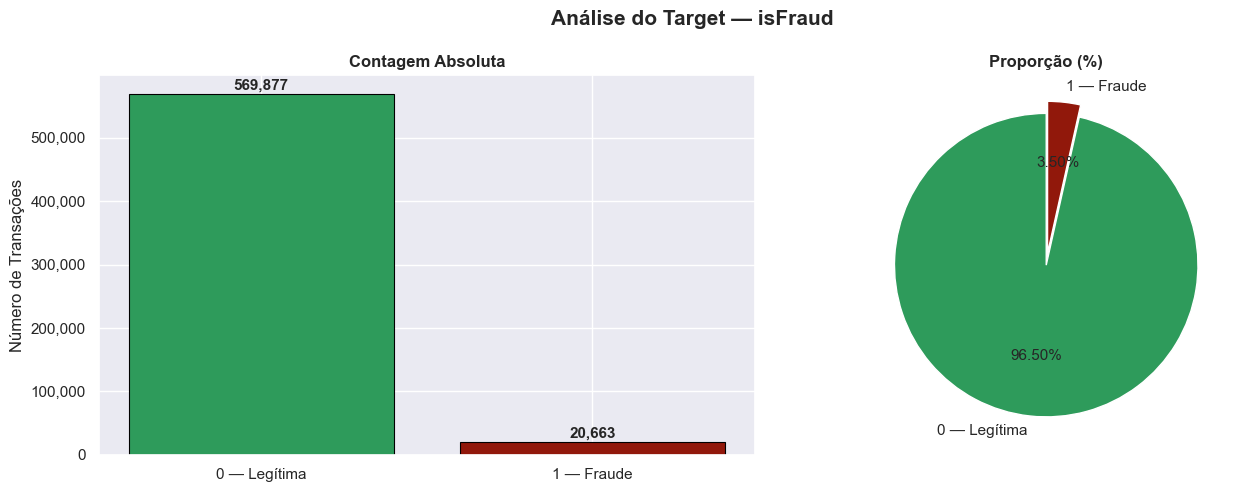

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Análise do Target — isFraud", fontsize=15, fontweight='bold')

cores  = ["#2e9b5b", "#91180b"]   # Verde = Legítima | Vermelho = Fraude
labels = ['0 — Legítima', '1 — Fraude']

# ── Gráfico 1: Barras (contagem absoluta) ──────────────────

ax1 = axes[0]
barras = ax1.bar(labels, contagem.values, color=cores,
                 edgecolor='black', linewidth=0.8)
ax1.set_title("Contagem Absoluta", fontsize=12, fontweight='bold')
ax1.set_ylabel("Número de Transações")
ax1.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

for barra, valor in zip(barras, contagem.values):
    ax1.text(barra.get_x() + barra.get_width() / 2,
             barra.get_height() + 1000,
             f'{valor:,}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')
    
# ── Gráfico 2: Pizza (proporção %) ─────────────────────────

ax2 = axes[1]
ax2.pie(percentual.values,
        labels=labels,
        colors=cores,
        autopct='%1.2f%%',
        startangle=90,
        explode=(0, 0.08),
        textprops={'fontsize': 11})
ax2.set_title("Proporção (%)", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()